# Exploratory Data Analysis (EDA) — SnapFlow
**Proyek:** AI Workplace Assistant (Klasifikasi Dokumen Internal Perusahaan)  
**Role:** NLP / Machine Learning Engineer

Notebook ini digunakan untuk membedah karakteristik dataset `dataset_clean.csv` sebelum masuk ke tahap pelatihan model IndoBERT

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Loading Dataset & Deskripsi Dasar

Pada tahap awal ini, kita akan memuat dataset bersih `dataset_clean.csv` ke dalam Pandas DataFrame untuk memeriksa struktur dasar data. Kita akan memvalidasi dimensi data (jumlah baris dan kolom), memastikan tipe data setiap kolom sudah sesuai, mengecek keberadaan nilai kosong (missing values), serta mendeteksi adanya duplikasi teks secara persis (*exact duplicates*).

**Tujuan:** Menjamin kualitas dan integritas data mentah sebelum dilakukan analisis statistik lebih mendalam.

In [3]:
df = pd.read_csv("../data/processed/dataset_clean.csv")

print("--- 5 Baris Pertama Data ---")
display(df.head())

print("\n--- Ringkasan Informasi Dataset ---")
print(f"Jumlah baris (sampel): {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

print("\n--- Pengecekan Missing Values (Data Kosong) ---")
print(df.isnull().sum())

print("\n--- Pengecekan Duplikasi Teks Secara Eksak ---")
jumlah_duplikat = df.duplicated(subset=['teks']).sum()
print(f"Jumlah baris data teks yang duplikat: {jumlah_duplikat}")

--- 5 Baris Pertama Data ---


,teks,kategori,prioritas
0,"Email dari Budi Santoso, Divisi Keuangan. Berd...",Laporan Keuangan,Tinggi
1,"Laporan dari Siti Rahmawati, Divisi Akuntansi....",Laporan Keuangan,Tinggi
2,"Email dari Andi Prasetyo, Divisi Treasury. Pos...",Laporan Keuangan,Tinggi
3,"Laporan dari Rina Kusuma, Divisi Audit Interna...",Laporan Keuangan,Tinggi
4,"Email dari Dedi Saputra, Divisi Pengadaan. Dit...",Laporan Keuangan,Tinggi



--- Ringkasan Informasi Dataset ---
Jumlah baris (sampel): 1005
Jumlah kolom: 3

--- Pengecekan Missing Values (Data Kosong) ---
teks         0
kategori     0
prioritas    0
dtype: int64

--- Pengecekan Duplikasi Teks Secara Eksak ---
Jumlah baris data teks yang duplikat: 0


## Distribusi Kelas (Class Balance)

Pada tahap ini, kita akan melakukan analisis sebaran kuantitatif pada kedua variabel target kita, yaitu `kategori` dan `prioritas`. Kita akan menghitung frekuensi kemunculan (*value counts*) beserta persentase proporsi dari masing-masing kelas, lalu memvisualisasikannya menggunakan grafik batang (*Bar Plot*).

**Tujuan:** Mendeteksi tingkat ketimpangan data (*class imbalance*). Distribusi kelas yang seimbang akan menentukan apakah kita memerlukan teknik penyeimbangan data khusus atau cukup menggunakan metode evaluasi standar.

--- Frekuensi Kelas Kategori Dokument ---
kategori
SOP                     222
Laporan Keuangan        210
Permintaan Pengadaan    210
Email HR                182
Tiket IT                181
Name: count, dtype: int64

--- Persentase Proporsi Kategori ---
kategori
SOP                     22.089552
Laporan Keuangan        20.895522
Permintaan Pengadaan    20.895522
Email HR                18.109453
Tiket IT                18.009950
Name: proportion, dtype: float64


--- Frekuensi Kelas Tingkat Prioritas ---
prioritas
Sedang    371
Tinggi    332
Rendah    302
Name: count, dtype: int64

--- Persentase Proporsi Prioritas ---
prioritas
Sedang    36.915423
Tinggi    33.034826
Rendah    30.049751
Name: proportion, dtype: float64


/tmp/ipykernel_8001/1918459793.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='kategori', ax=axes[0], order=df['kategori'].value_counts().index, palette='viridis')
/tmp/ipykernel_8001/1918459793.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='prioritas', ax=axes[1], order=df['prioritas'].value_counts().index, palette='magma')


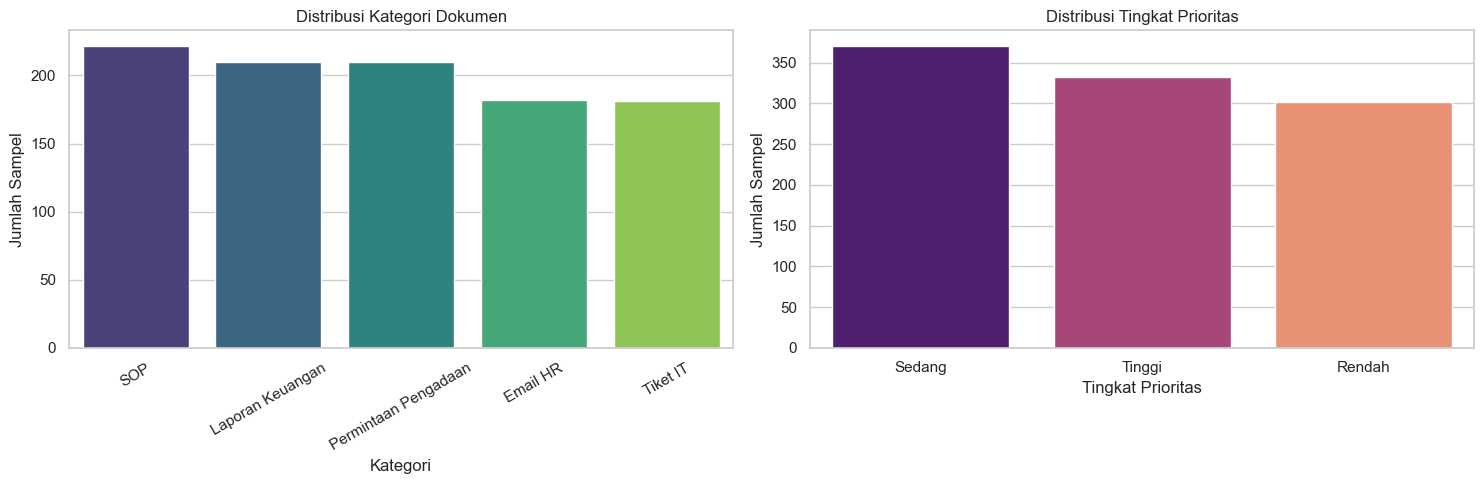

In [4]:
print("--- Frekuensi Kelas Kategori Dokument ---")
print(df['kategori'].value_counts())
print("\n--- Persentase Proporsi Kategori ---")
print(df['kategori'].value_counts(normalize=True) * 100)

print("\n" + "="*40 + "\n")

print("--- Frekuensi Kelas Tingkat Prioritas ---")
print(df['prioritas'].value_counts())
print("\n--- Persentase Proporsi Prioritas ---")
print(df['prioritas'].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, x='kategori', ax=axes[0], order=df['kategori'].value_counts().index, palette='viridis')
axes[0].set_title("Distribusi Kategori Dokumen")
axes[0].set_xlabel("Kategori")
axes[0].set_ylabel("Jumlah Sampel")
axes[0].tick_params(axis='x', rotation=30)

sns.countplot(data=df, x='prioritas', ax=axes[1], order=df['prioritas'].value_counts().index, palette='magma')
axes[1].set_title("Distribusi Tingkat Prioritas")
axes[1].set_xlabel("Tingkat Prioritas")
axes[1].set_ylabel("Jumlah Sampel")

plt.tight_layout()
plt.show()

## Analisis Korelasi Label Ganda (Cross-Tabulation)

Karena SnapFlow menerapkan klasifikasi ganda, dokumen yang sama akan memiliki label kategori sekaligus prioritas. Di sini, kita akan membuat tabel silang (*Cross-Tabulation*) untuk menghitung distribusi sebaran tingkat prioritas di dalam setiap kategori dokumen. Hasil tabel ini kemudian divisualisasikan menggunakan *Heatmap* agar polanya lebih mudah dibaca.

**Tujuan:** Menganalisis apakah terdapat korelasi atau ketergantungan yang kuat antara kategori dokumen tertentu dengan tingkat prioritas spesifik yang dihasilkan oleh AI generator.

--- Tabel Silang (Frekuensi Riil) ---


prioritas,Rendah,Sedang,Tinggi
kategori,,,
Email HR,60,62,60
Laporan Keuangan,35,70,105
Permintaan Pengadaan,35,105,70
SOP,112,73,37
Tiket IT,60,61,60




--- Tabel Silang (Persentase Per Kategori) ---


prioritas,Rendah,Sedang,Tinggi
kategori,,,
Email HR,32.97,34.07,32.97
Laporan Keuangan,16.67,33.33,50.00
Permintaan Pengadaan,16.67,50.00,33.33
SOP,50.45,32.88,16.67
Tiket IT,33.15,33.70,33.15


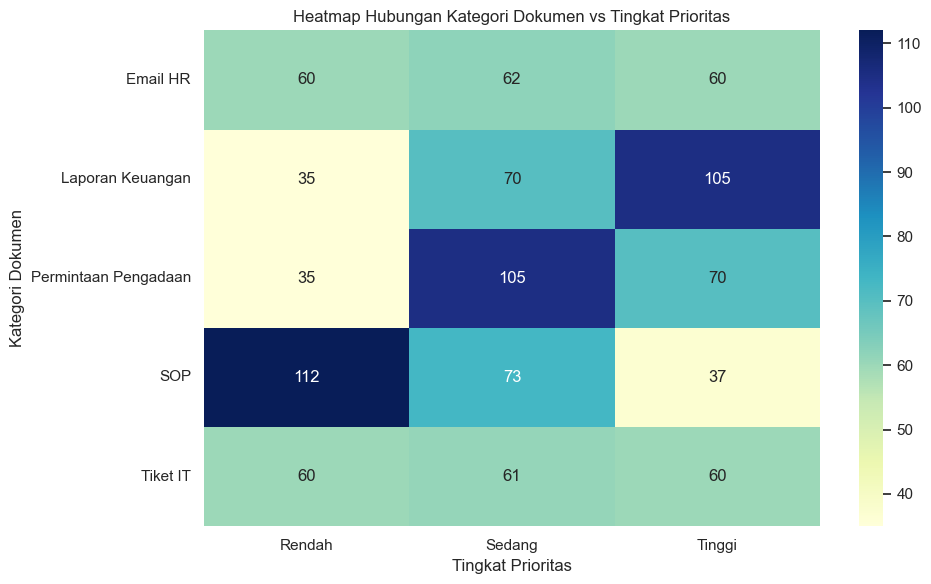

In [5]:
tabel_silang_freq = pd.crosstab(df['kategori'], df['prioritas'])
print("--- Tabel Silang (Frekuensi Riil) ---")
display(tabel_silang_freq)

print("\n" + "="*40 + "\n")

tabel_silang_pct = pd.crosstab(df['kategori'], df['prioritas'], normalize='index') * 100
print("--- Tabel Silang (Persentase Per Kategori) ---")
display(tabel_silang_pct.round(2))

plt.figure(figsize=(10, 6))
sns.heatmap(tabel_silang_freq, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title("Heatmap Hubungan Kategori Dokumen vs Tingkat Prioritas")
plt.ylabel("Kategori Dokumen")
plt.xlabel("Tingkat Prioritas")
plt.tight_layout()
plt.show()

## Analisis Karakteristik Panjang Teks (Kata & Token)

Arsitektur Transformer seperti IndoBERT memiliki batasan maksimal panjang urutan token (*max sequence length*). Pada langkah ini, kita akan mengekstrak jumlah kata dari setiap dokumen teks dan menghitung statistik deskriptifnya (mean, median, nilai minimum, nilai maksimum, serta kuartil 75%). Kita juga akan menampilkan grafik *Histogram* sebaran panjang kata dan menyaring dokumen yang menjadi *outlier* terpanjang.

**Tujuan:** Menentukan konfigurasi ukuran `MAX_LENGTH` yang paling optimal dan aman untuk proses tokenisasi model IndoBERT, serta mengidentifikasi adanya *noise* pada teks yang terlalu panjang.

--- Statistik Deskriptif Panjang Kata ---
count    1005.000000
mean       53.894527
std        20.447260
min        31.000000
25%        38.000000
50%        48.000000
75%        65.000000
max       189.000000
Name: jumlah_kata, dtype: float64


--- Median Panjang Kata Per Kategori ---
kategori
Email HR                69.0
Permintaan Pengadaan    58.5
Tiket IT                50.0
SOP                     40.0
Laporan Keuangan        37.0
Name: jumlah_kata, dtype: float64


/tmp/ipykernel_8001/2518654142.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='jumlah_kata', y='kategori', ax=axes[1], palette='Set2')


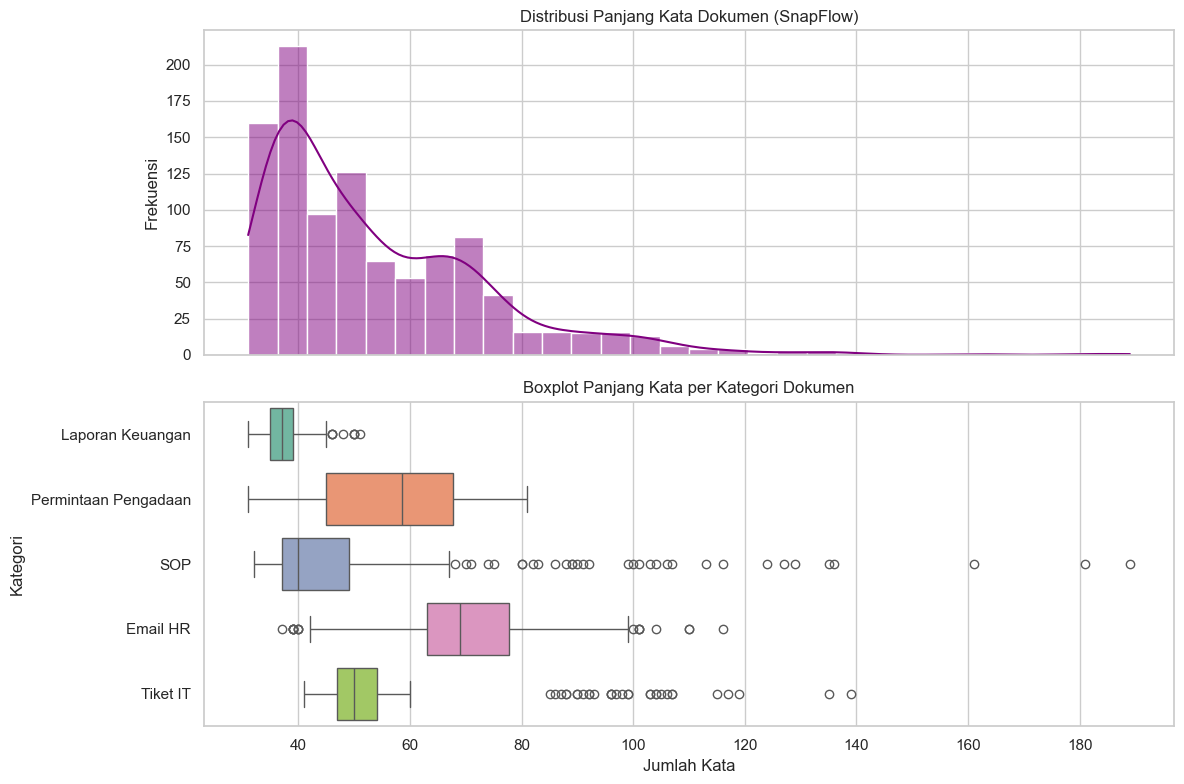



--- Investigasi Sampel Teks SOP Terpanjang (> 150 kata) ---
Index: 639 | Jumlah Kata: 161 | Prioritas: Rendah
Teks:
Pengelolaan jadwal pemakaian kursi pijat relaksasi di sudut istirahat ruang hobi hiburan staf operasional malam hanya aktif dinyalakan panel utama kontrol setrum listriknya sewaktu jeda shift tiga dari jam sebelas malam sampai bergantian waktu salat subuhnya memecah hening waktu jam padat shift ke shiftnya saja. Petugas kebersihan bertugas rutin setiap sore mengelap pembersih bahan disinfektan usap anti bakteri ke material pelapis berbahan kulit imitasi tempat santai guna menghindari transfer penularan penyakit jamur kulit antar karyawan gonta ganti yang sering tertidur lelap sandaran peluh keringatnya tak beraturan menempel kotor di bantalan bahu busanya kursi tersebut di sisa sisa rehat shift melelahkan mereka di lantai kerjanya. Karyawan siapapun tak diperbolehkan menggunakan fasilitas sarana terapi santai kursi elektronik putar putar getar alat bermesin dinamo roda 

In [6]:
df['jumlah_kata'] = df['teks'].apply(lambda x: len(str(x).split()))

print("--- Statistik Deskriptif Panjang Kata ---")
print(df['jumlah_kata'].describe())

print("\n" + "="*40 + "\n")

print("--- Median Panjang Kata Per Kategori ---")
print(df.groupby('kategori')['jumlah_kata'].median().sort_values(ascending=False))


fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.histplot(data=df, x='jumlah_kata', kde=True, ax=axes[0], color='purple', bins=30)
axes[0].set_title("Distribusi Panjang Kata Dokumen (SnapFlow)")
axes[0].set_ylabel("Frekuensi")

sns.boxplot(data=df, x='jumlah_kata', y='kategori', ax=axes[1], palette='Set2')
axes[1].set_title("Boxplot Panjang Kata per Kategori Dokumen")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Kategori")

plt.tight_layout()
plt.show()

print("\n" + "="*40 + "\n")

print("--- Investigasi Sampel Teks SOP Terpanjang (> 150 kata) ---")
sop_outliers = df[(df['kategori'] == 'SOP') & (df['jumlah_kata'] > 150)]
if not sop_outliers.empty:
    for idx, row in sop_outliers.head(2).iterrows():
        print(f"Index: {idx} | Jumlah Kata: {row['jumlah_kata']} | Prioritas: {row['prioritas']}")
        print(f"Teks:\n{row['teks']}\n")
else:
    print("Tidak ditemukan teks SOP di atas 150 kata.")

## Analisis Leksikal & Kata Kunci Dominan (N-Gram & TF-IDF)

Pada tahap ini, kita akan mengeksplorasi kandungan kosakata (*vocabulary*) unik yang mencirikan masing-masing dari 5 kategori dokumen perusahaan. Dengan bantuan pembobotan TF-IDF dan penghapusan *stopword* bahasa Indonesia secara lokal (khusus untuk visualisasi), kita akan mendaftar Top-10 kata kunci dominan serta membuat visualisasi *Word Cloud* per kategori.

**Tujuan:** Memvalidasi secara linguistik apakah dokumen sintetik pada tiap-tiap divisi beneran memiliki ciri khas kata pembeda yang logis dan relevan dengan operasional dunia nyata.

--- TOP 10 KEYWORDS PER KATEGORI (TF-IDF) ---
Kategori [Laporan Keuangan]: 000, anggaran, biaya, bulan, kebutuhan, operasional, pengeluaran, perusahaan, rp, sebesar
Kategori [Permintaan Pengadaan]: 000, biaya, estimasi, harga, mengajukan, pengadaan, pengajuan, rp, total, unit
Kategori [SOP]: hari, harus, karyawan, kerja, langsung, perusahaan, secara, setiap, tim, wajib
Kategori [Email HR]: cuti, hari, hr, hrd, ingin, kasih, kerja, perusahaan, terima, tim
Kategori [Tiket IT]: akses, aplikasi, baru, halo, ingin, it, laptop, pagi, saat, tim


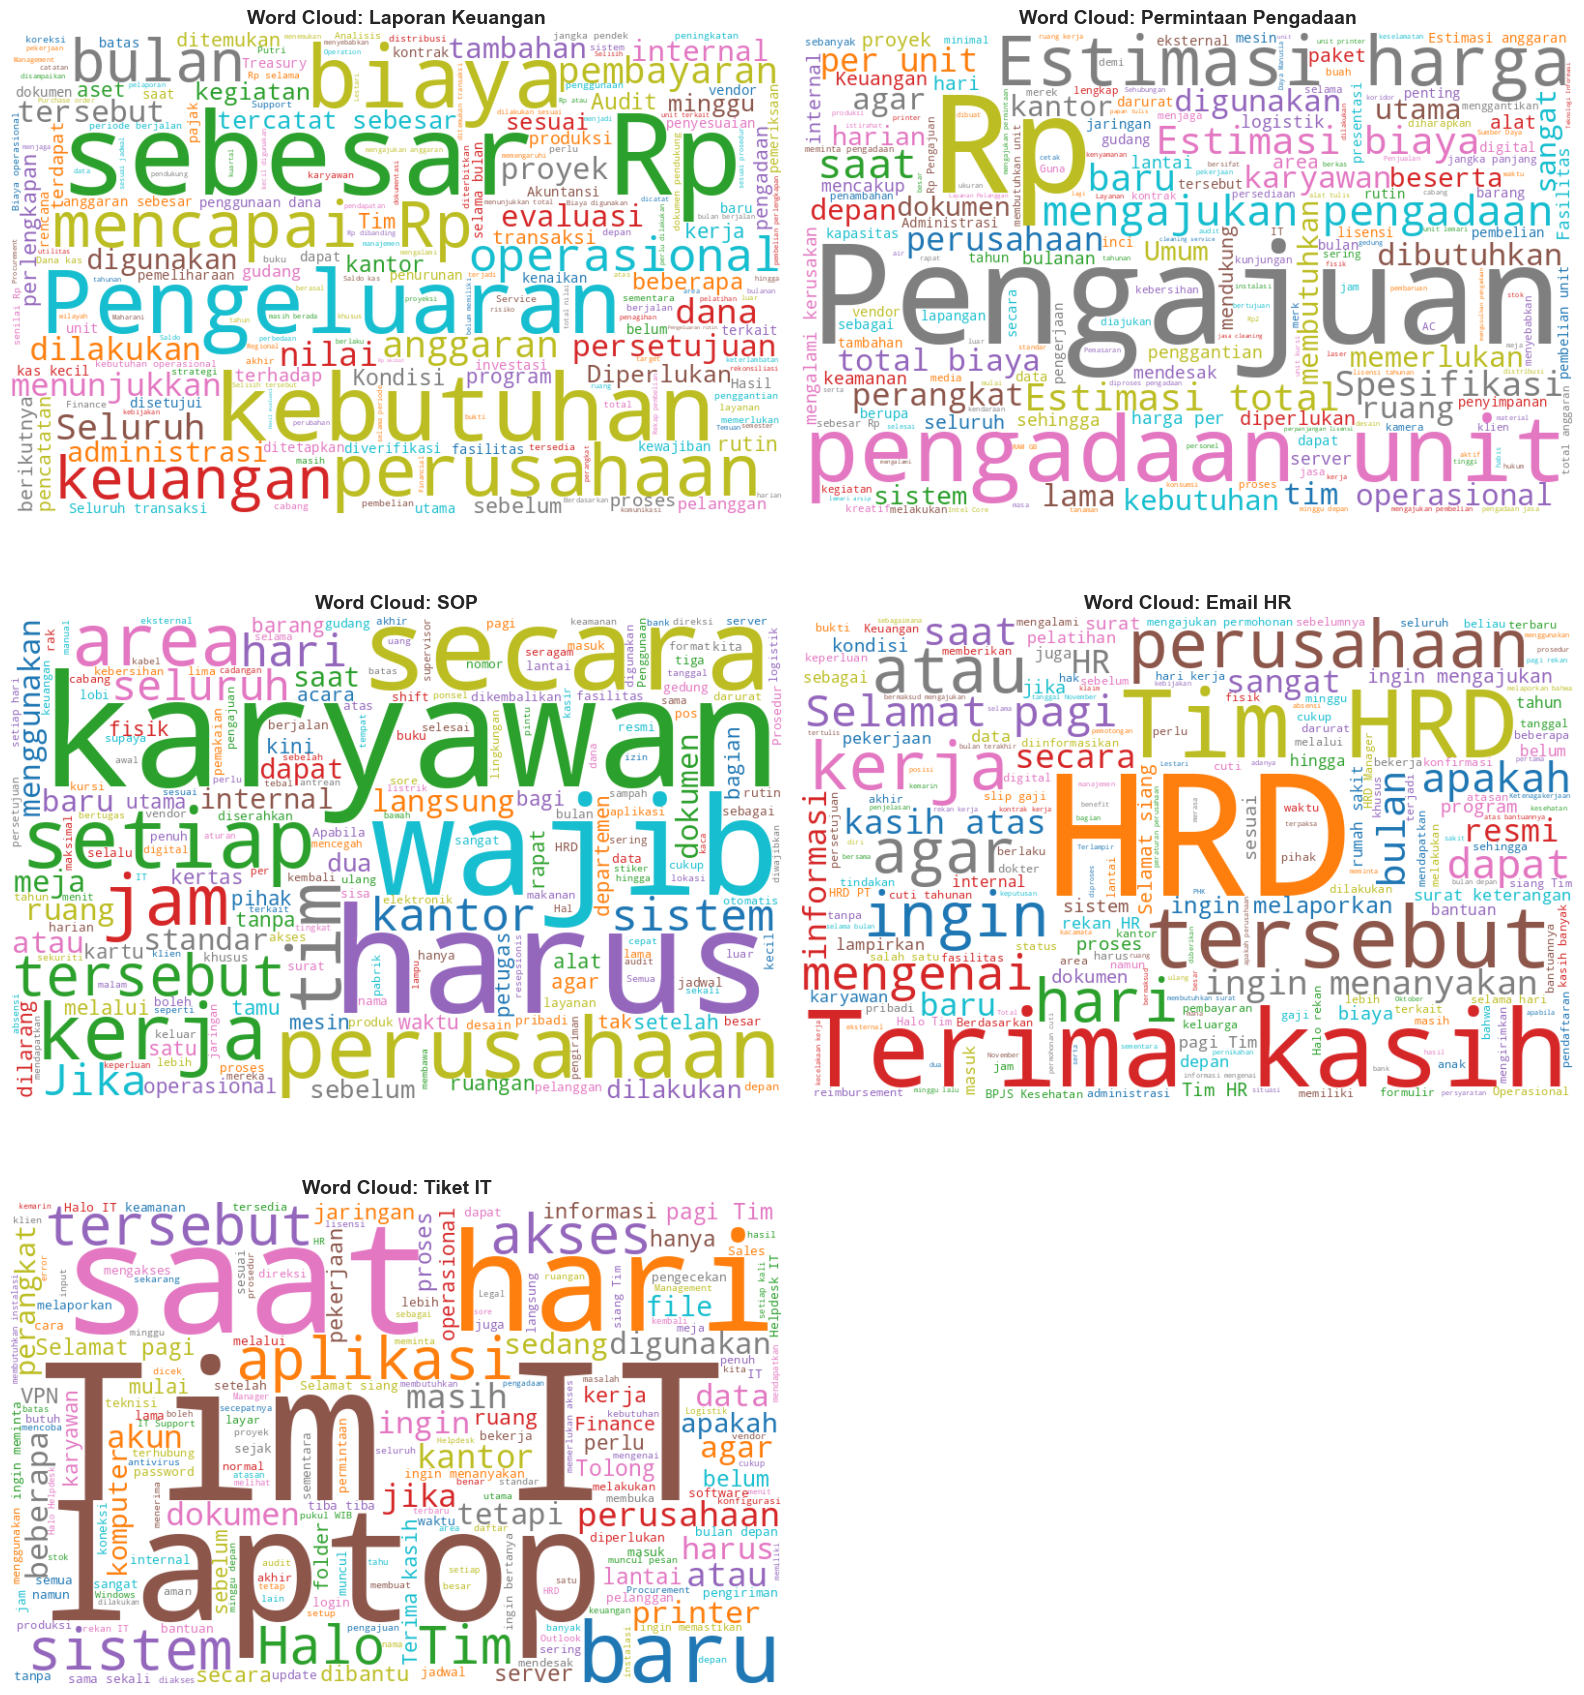

In [7]:
stop_words_id = [
    'dan', 'yang', 'di', 'ke', 'dari', 'untuk', 'saya', 'ini', 'itu', 'dengan', 
    'ada', 'adalah', 'bisa', 'tidak', 'telah', 'saja', 'akan', 'kami', 'saya', 
    'oleh', 'dari', 'bapak', 'ibu', 'selaku', 'kepada', 'yth', 'terhormat', 
    'mohon', 'segera', 'untuk', 'pada', 'dalam', 'bisa', 'karena', 'sudah', 
    'laporan', 'email', 'divisi', 'staf', 'manajer', 'ext', 'hp'
]

kategori_list = df['kategori'].unique()

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

print("--- TOP 10 KEYWORDS PER KATEGORI (TF-IDF) ---")

for i, kat in enumerate(kategori_list):
    teks_kat = df[df['kategori'] == kat]['teks']
    
    tfidf = TfidfVectorizer(stop_words=stop_words_id, max_features=10)
    tfidf.fit(teks_kat)
    top_keywords = tfidf.get_feature_names_out()
    
    print(f"Kategori [{kat}]: {', '.join(top_keywords)}")
    
    gabungan_teks = " ".join(teks_kat.tolist())
    
    wordcloud = WordCloud(
        width=800, 
        height=500, 
        background_color='white', 
        stopwords=set(stop_words_id),
        colormap='tab10'
    ).generate(gabungan_teks)
    
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f"Word Cloud: {kat}", fontsize=14, fontweight='bold')
    axes[i].axis('off')


fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## Visualisasi Sebaran Fitur (Embedding Space Visualization)

Langkah terakhir dari EDA ini adalah melakukan proyeksi ruang fitur. Kita akan mengubah seluruh teks dokumen ke dalam representasi angka berdimensi tinggi menggunakan TF-IDF, lalu menggunakan algoritma reduksi dimensi **t-SNE** (atau UMAP) untuk memproyeksikannya ke dalam koordinat 2 dimensi (2D) berupa *Scatter Plot* berwarna berdasarkan kategori.

**Tujuan:** Melihat secara visual keterpisahan antarkelas (*class separability*). Jika klaster warna mengelompok secara alami dan terpisah rapi, artinya tugas klasifikasi ini akan lebih mudah dipelajari secara akurat oleh model IndoBERT.

--- Memproses Reduksi Dimensi t-SNE (Sila Tunggu Sebentar...) ---


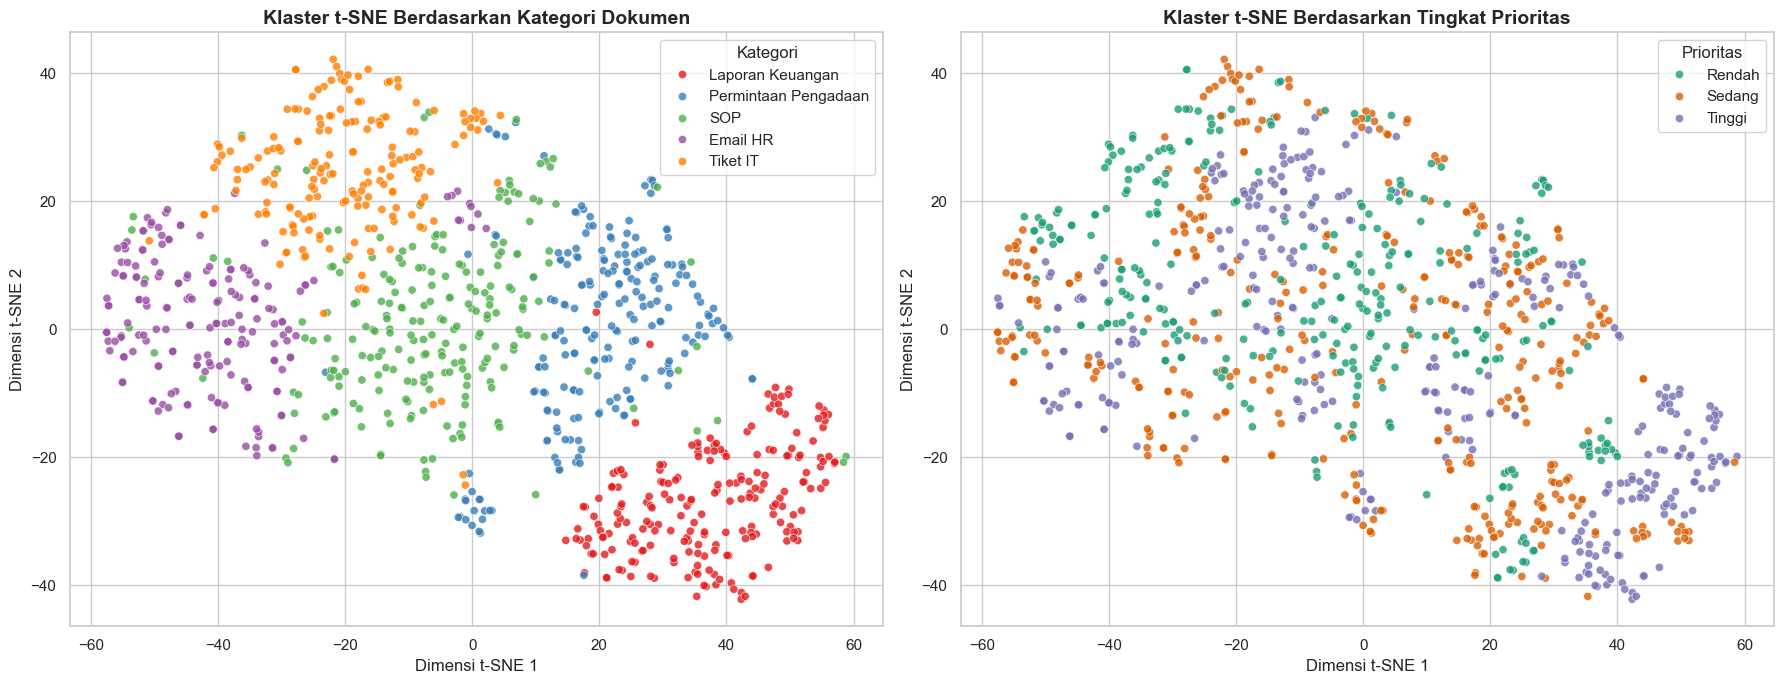

Proses Visualisasi t-SNE Selesai!


In [10]:
print("--- Memproses Reduksi Dimensi t-SNE (Sila Tunggu Sebentar...) ---")

tfidf_vectorizer = TfidfVectorizer(max_features=500, stop_words=stop_words_id)
X_tfidf = tfidf_vectorizer.fit_transform(df['teks']).toarray()

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_tfidf)

df_tsne = pd.DataFrame({
    'TSNE-1': X_tsne[:, 0],
    'TSNE-2': X_tsne[:, 1],
    'Kategori': df['kategori'],
    'Prioritas': df['prioritas']
})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=df_tsne, x='TSNE-1', y='TSNE-2', 
    hue='Kategori', palette='Set1', alpha=0.8, ax=axes[0]
)
axes[0].set_title("Klaster t-SNE Berdasarkan Kategori Dokumen", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Dimensi t-SNE 1")
axes[0].set_ylabel("Dimensi t-SNE 2")

sns.scatterplot(
    data=df_tsne, x='TSNE-1', y='TSNE-2', 
    hue='Prioritas', palette='Dark2', alpha=0.8, ax=axes[1],
    hue_order=['Rendah', 'Sedang', 'Tinggi']
)
axes[1].set_title("Klaster t-SNE Berdasarkan Tingkat Prioritas", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Dimensi t-SNE 1")
axes[1].set_ylabel("Dimensi t-SNE 2")

plt.tight_layout()
plt.show()

print("Proses Visualisasi t-SNE Selesai!")